# Wilson-Cowan Pairwise Model

---
## **1. Theoretical Introduction**

### **1.1. Wilson-Cowan Model**
The Wilson-Cowan model describes the dynamics of excitatory (E) and inhibitory (I) neural populations with pairwise interactions.

#### **Model Equations:**
- **Excitatory Population:**
  $$
  \tau_E \frac{dE_i}{dt} = -E_i + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)
  $$

- **Inhibitory Population:**
  $$
  \tau_I \frac{dI_i}{dt} = -I_i + S\left(c_{EI} E_i - c_{II} I_i + Q\right)
  $$

#### **Sigmoid Function:**
$$
S(v) = \frac{1}{1 + e^{-a v}}
$$

---
## **2. Initial Setup**
We import the functions already defined in the `Scripts` folder.


In [2]:
import sys
sys.path.append('../')  # Ensure Python can find the 'Scripts' folder

from Scripts.parameters import *
from Scripts.dynamics import *
from Scripts.simulation import *
from Scripts.oscillation_detection import *
from Scripts.metrics import *
from Scripts.visualization import *

print("Functions loaded successfully.")

Stable Rank: 1.50
Nuclear Rank: 2.00
Effective Rank (Energy Ratio 95%): 3
Functions loaded successfully.


---
## **3. Basic Simulation and Signal Plotting**
We simulate the model with default parameters and visualize the signals.


Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4948, std=0.1679, range=[0.2560, 0.7439]
  I: mean=0.4684, std=0.0854, range=[0.3420, 0.6025]

Node 1:
  E: mean=0.4957, std=0.1693, range=[0.2499, 0.7629]
  I: mean=0.4686, std=0.0855, range=[0.3416, 0.6028]

Node 2:
  E: mean=0.4952, std=0.1687, range=[0.2521, 0.7574]
  I: mean=0.4685, std=0.0855, range=[0.3412, 0.6035]


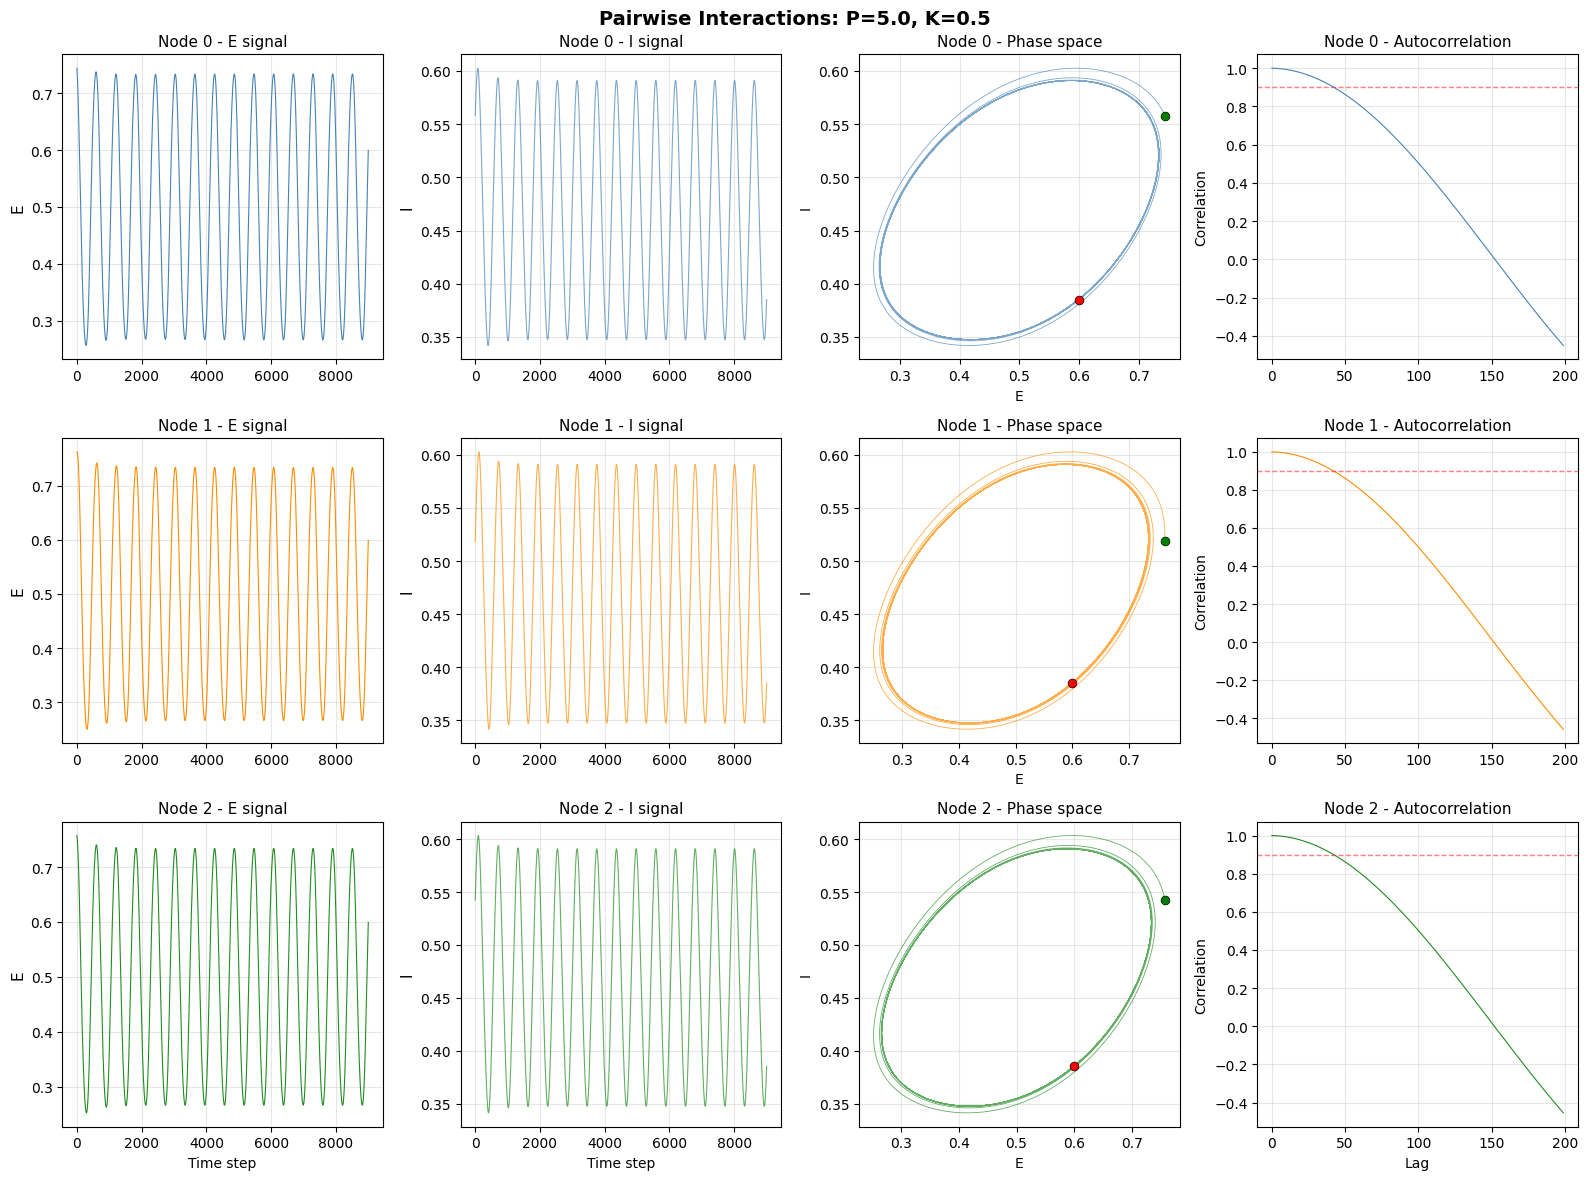

In [3]:
# Simulation parameters
P_sim = 5.0
K_sim = 0.5

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

# Simulation using the existing function
t, states = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")


In [ ]:
# Importar solo lo necesario
from Scripts.parameters import *
from Scripts.reduction_utils import *
from Scripts.reduced_dynamics import *
from Scripts.reduced_simulation import *

# --- Paso 1: Calcular parámetros reducidos ---
M_reduced = calculate_reduction_matrix(M, effective_rank=2)
D_reduced = calculate_D_reduced(M_reduced, tauE)
W_reduced = calculate_W_reduced(M_reduced, M, K=0.5)

# --- Paso 2: Estado inicial ---
state0 = 0.1 * np.random.randn(2 * N_nodes)
I0 = state0[N_nodes:]
state0_reduced = M_reduced.T @ state0[:N_nodes]

# --- Paso 3: Simulación reducida ---
t, states_2d, I_states = simulate_reduced_wc_dynamic_I(
    state0_reduced, I0, P_sim=5.0, K_sim=0.5, M=M, M_reduced=M_reduced,
    D_reduced=D_reduced, W_reduced=W_reduced, T=T, dt=dt
)

# --- Paso 4: Reconstruir E ---
E_reduced = M_reduced.T @ states_2d.T

# --- Paso 5: Visualización ---
from functions.visualization import plot_detailed_signals

# Construir states_reduced para plot_detailed_signals
states_reduced = np.zeros((len(t), 2 * N_nodes))
states_reduced[:, :N_nodes] = E_reduced.T
states_reduced[:, N_nodes:] = I_states

plot_detailed_signals(t, states_reduced, N_nodes, P_sim=5.0, K_sim=0.5, title="Modelo Reducido - Pairwise")


[[8.33333333 0.         0.        ]
 [0.         8.33333333 0.        ]
 [0.         0.         8.33333333]]
[[-0.57735027 -0.57735027]
 [-0.          0.70710678]
 [-0.81649658  0.40824829]]
[[-0.57735027 -0.         -0.81649658]
 [-0.57735027  0.70710678  0.40824829]]
[[-8.33333333e+00 -1.12974996e-16]
 [-1.58299661e-16 -8.33333333e+00]]


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 2)

---
## **4. Oscillation Detection in $(P \times K$) Space**
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


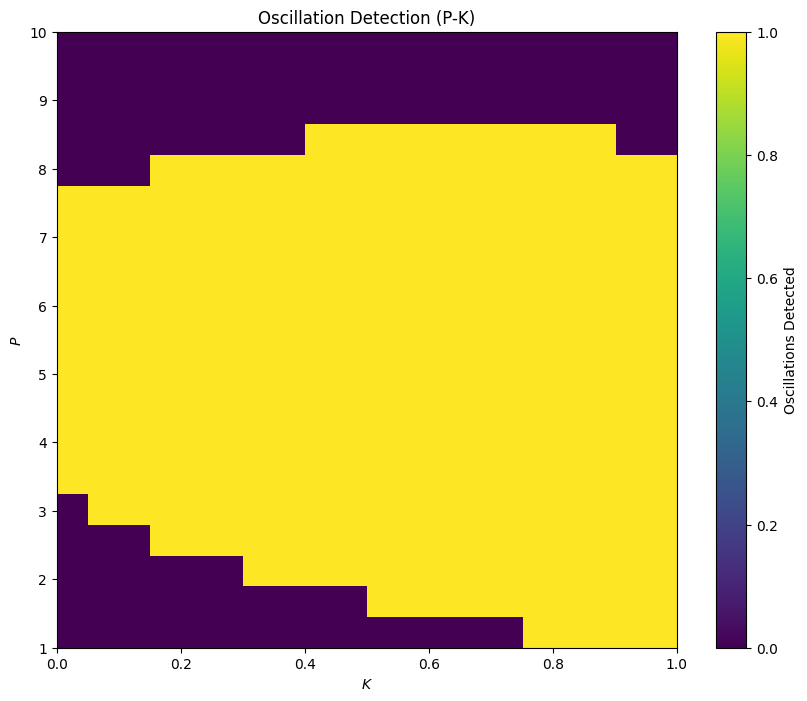

In [4]:
# Matrix to store oscillation detection
oscillation_map = np.zeros((len(P_values), len(K_values)), dtype=int)

# Initial state
state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation using the existing function
        t, states = simulate_wc(state0, P_val, K_val, M, T, dt)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt)
        oscillation_map[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map, P_values, K_values, title="Oscillation Detection (P-K)")


---
## **5. Higher-Order Metrics**
We calculate higher-order metrics to analyze interactions in the system.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


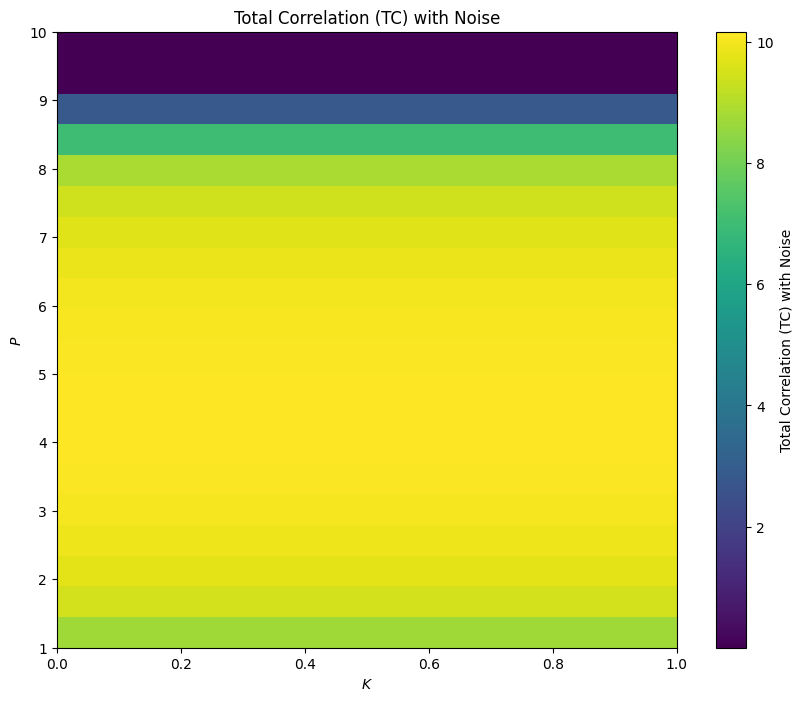

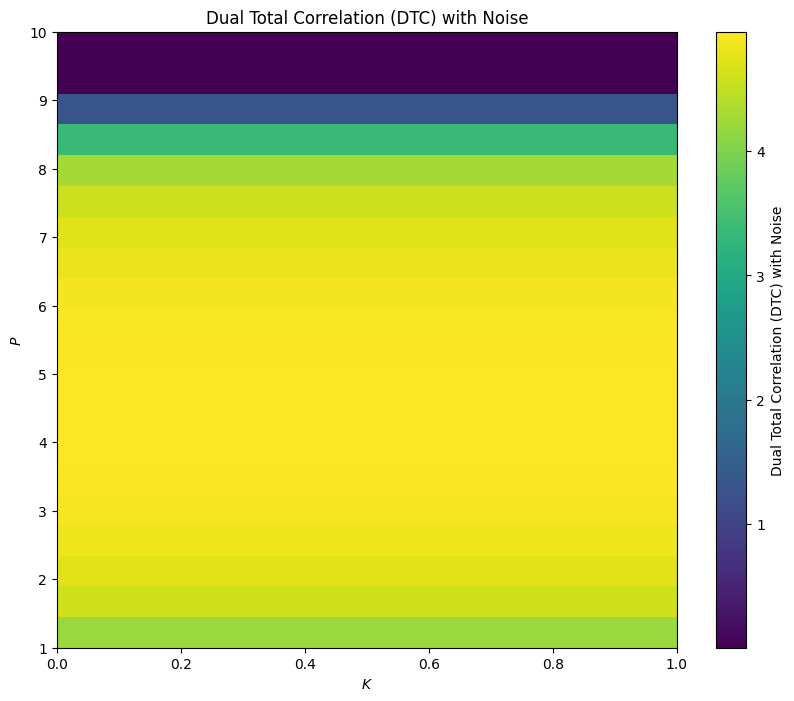

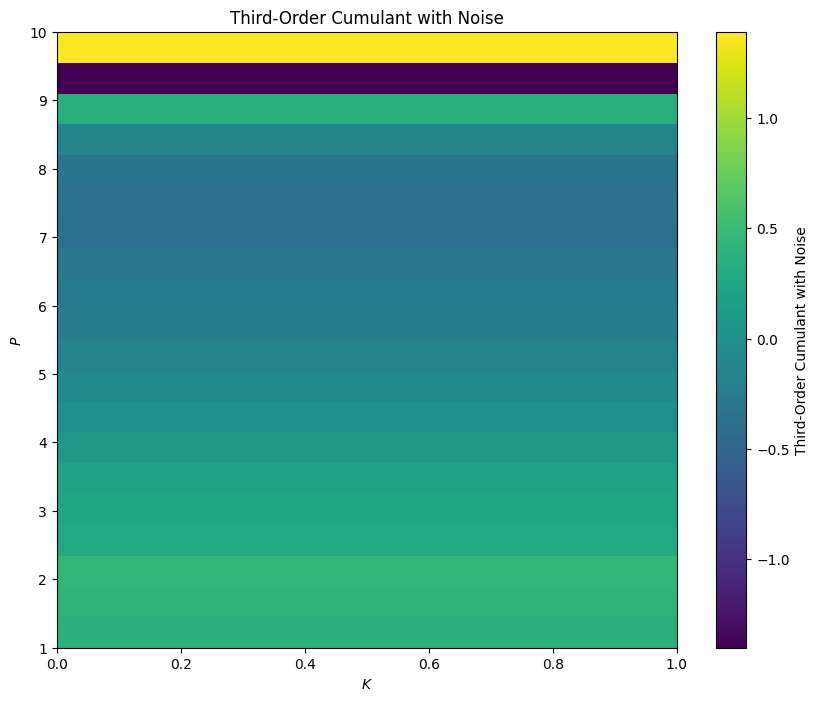

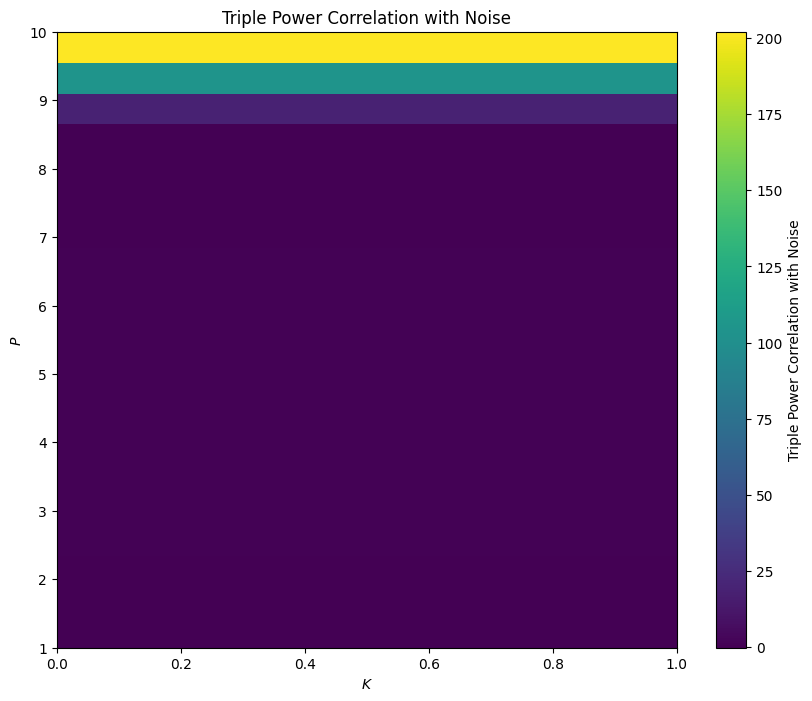

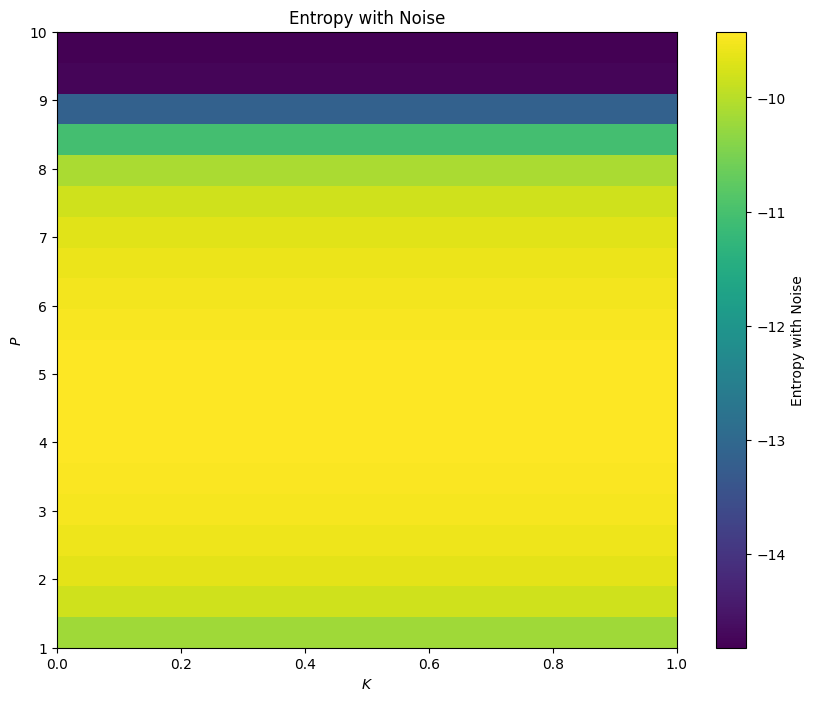

In [5]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc(state0, P_val, K_val, M, T, dt)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise") 

---
## **6. Model with Stochastic Noise**
We add stochastic noise to the excitatory population (E) using the Euler-Maruyama method.

To include biological noise, we extend the excitatory population dynamics using the **Euler-Maruyama method**:

$$
E_i(t + \Delta t) = E_i(t) + \frac{\Delta t}{\tau_E} \left(-E_i(t) + S\left(c_{EE} E_i - c_{IE} I_i + P + K \sum_{j} M_{ij} E_j\right)\right)+ \frac{\sigma_E \sqrt{\Delta t}}{\tau_E} \xi_i
$$

- $(\sigma_E)$: Noise intensity for the excitatory population.
- $(\xi_i \sim \mathcal{N}(0, 1))$: Gaussian white noise.

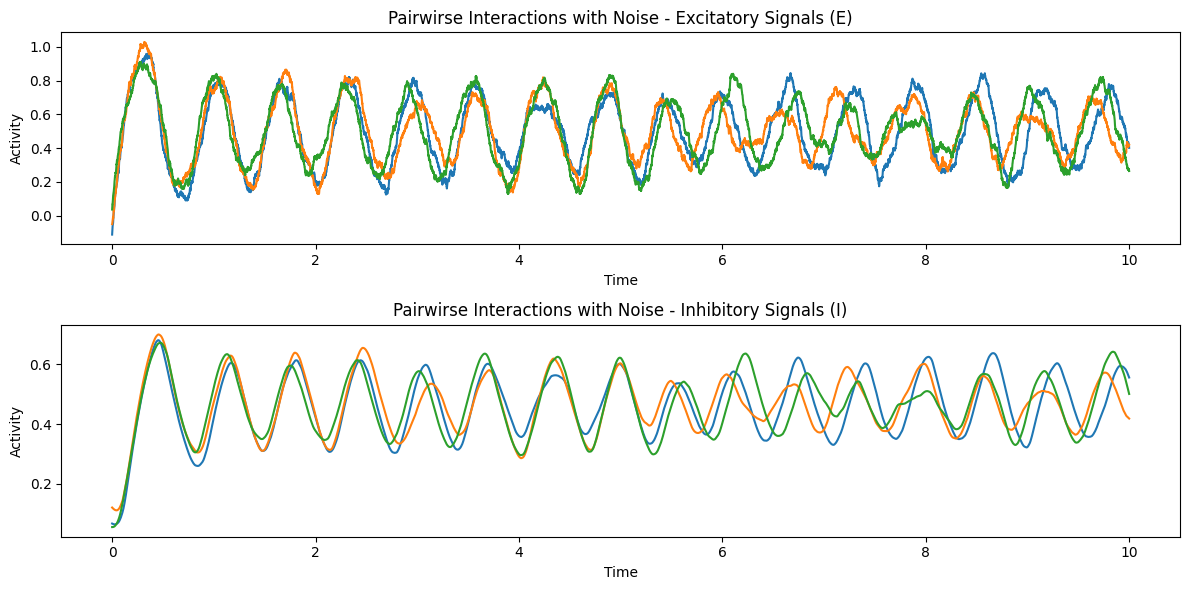

Total timesteps: 10000
Analysis timesteps: 9001

Node 0:
  E: mean=0.4998, std=0.1877, range=[0.1263, 0.8444]
  I: mean=0.4691, std=0.0926, range=[0.3033, 0.6374]

Node 1:
  E: mean=0.4982, std=0.1679, range=[0.1292, 0.8646]
  I: mean=0.4696, std=0.0843, range=[0.2855, 0.6550]

Node 2:
  E: mean=0.4981, std=0.1790, range=[0.1290, 0.8402]
  I: mean=0.4692, std=0.0910, range=[0.2957, 0.6420]


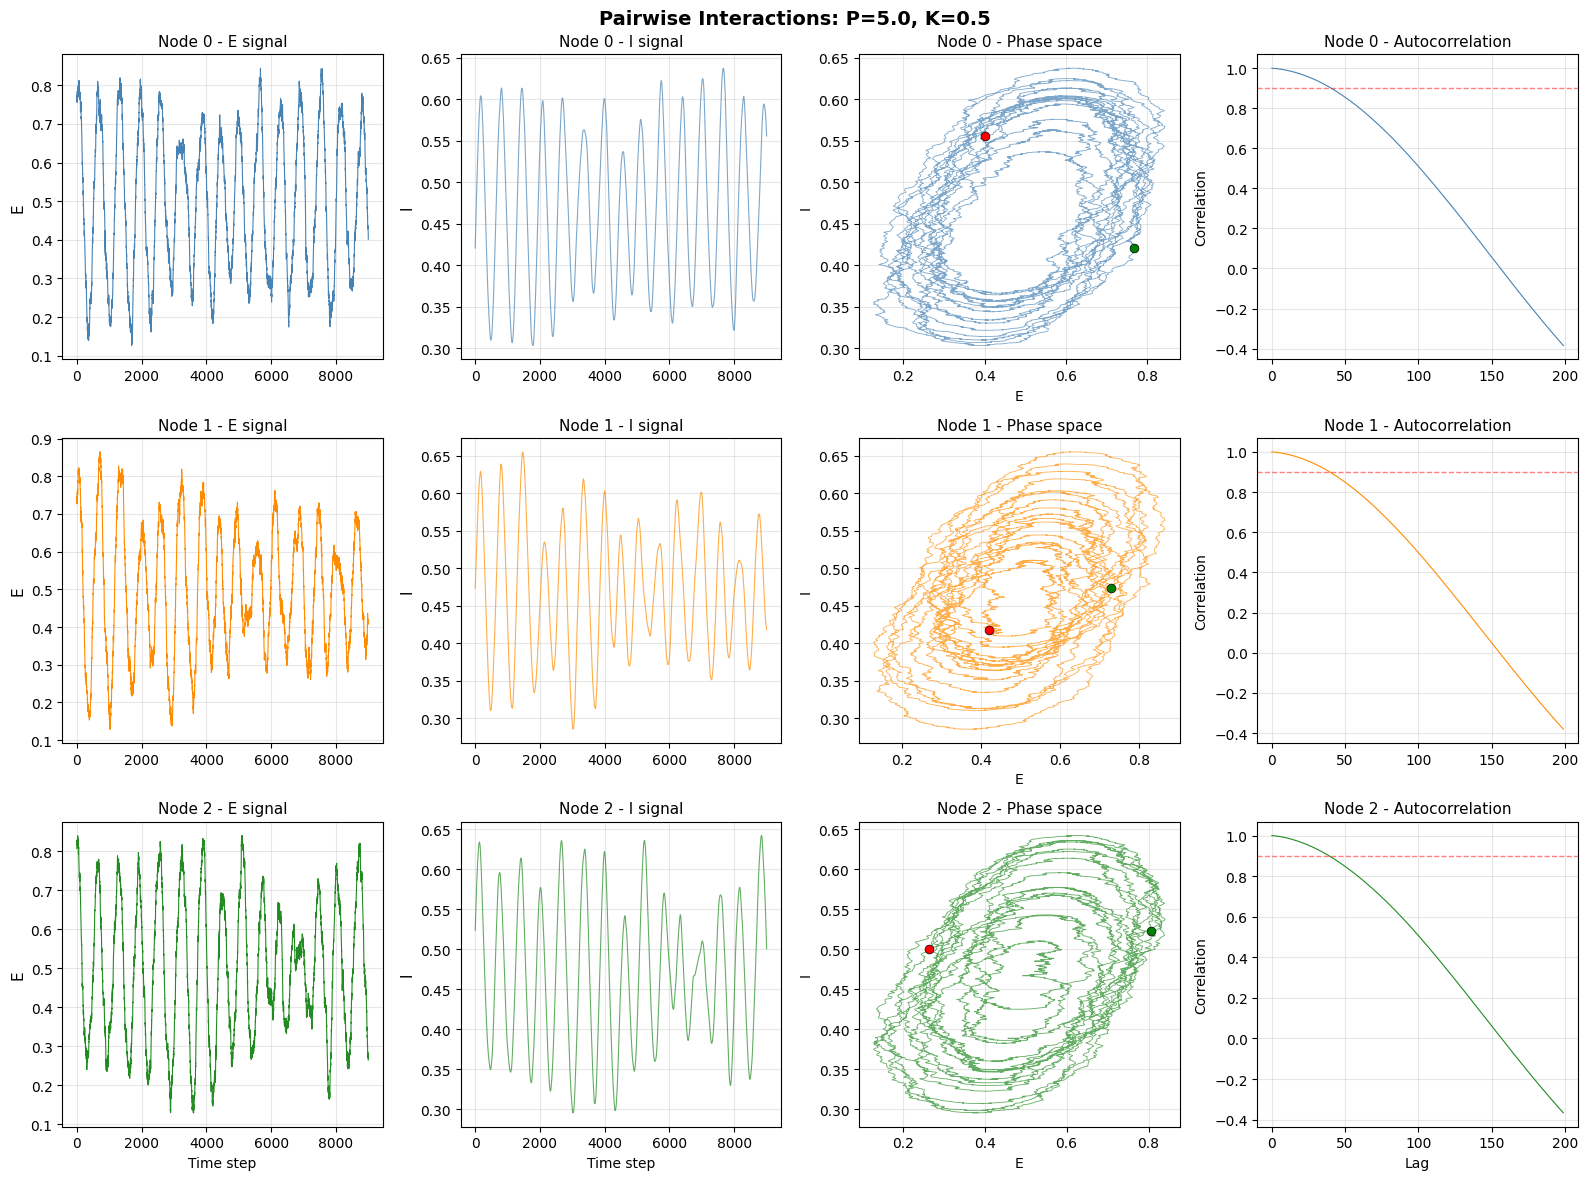

In [13]:
# Simulation parameters with noise
sigma_E = 0.02

# Simulation with noise using the existing function
t, states = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E, higher_order=False)

# Extract signals
E = states[:, :N_nodes]
I = states[:, N_nodes:]

# Visualization using the existing function
plot_signals(t, E, I, title="Pairwirse Interactions with Noise")
# Visualization using the existing function
plot_detailed_signals(t, states, N_nodes, P_sim=P_sim, K_sim=K_sim, title="Pairwise Interactions")


---
## **7. Oscillation Detection in $(P \times K$) Space** with noise
We perform a parameter sweep to detect oscillations in the $(P \times K$) space.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


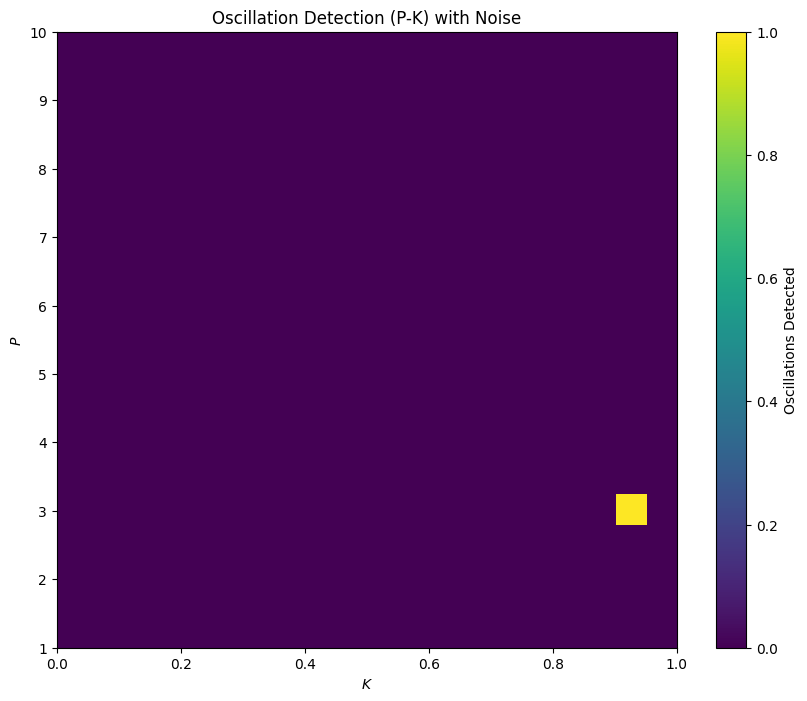

In [27]:
# Matrix to store oscillation detection with noise
oscillation_map_noise = np.zeros((len(P_values), len(K_values)), dtype=int)

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K_val in enumerate(K_values):
        # Simulation with noise using the existing function
        t, states = simulate_wc_stochastic(state0, P_val, K_val, M, T, dt, sigma_E=sigma_E, higher_order=False)

        # Remove transient
        start_idx = len(states) // 2
        E = states[start_idx:, :N_nodes]
        I = states[start_idx:, N_nodes:]

        E_node = E[:, 0]
        I_node = I[:, 0]

        # Oscillation detection using the existing function
        is_lc, _, _, _ = detect_limit_cycle_poincare(E_node, I_node, dt, 0.1,0.1)
        oscillation_map_noise[i, j] = int(is_lc)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing function
plot_oscillation_map(oscillation_map_noise, P_values, K_values, title="Oscillation Detection (P-K) with Noise")


---
## **8. Higher-Order Metrics with noise**
We calculate higher-order metrics to analyze interactions in the system.


Progress: 5/20
Progress: 10/20
Progress: 15/20
Progress: 20/20


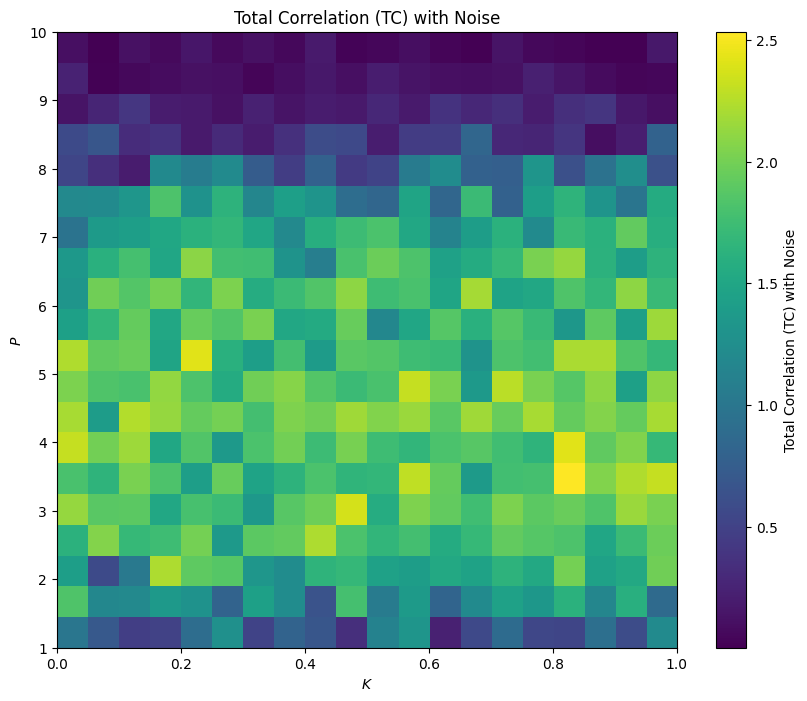

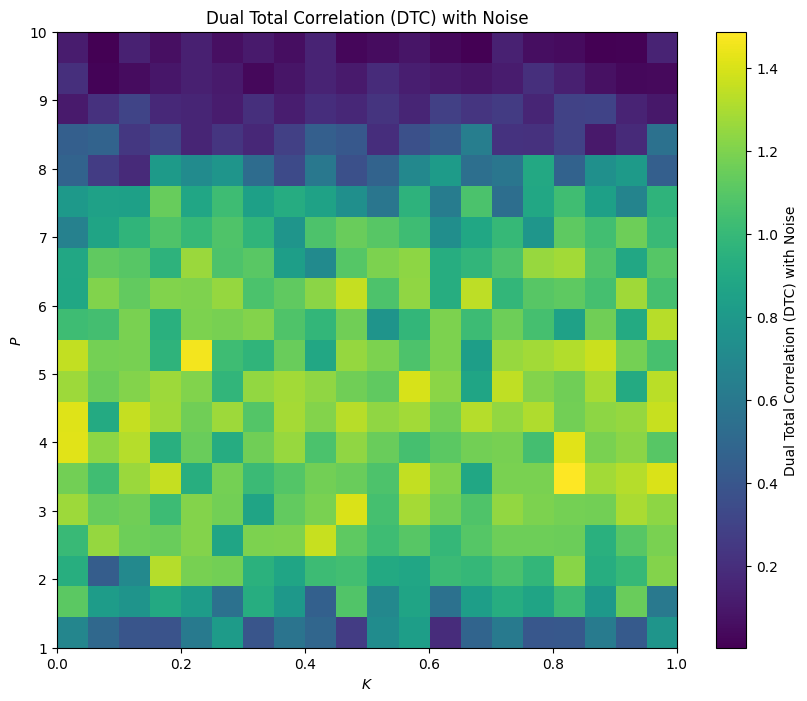

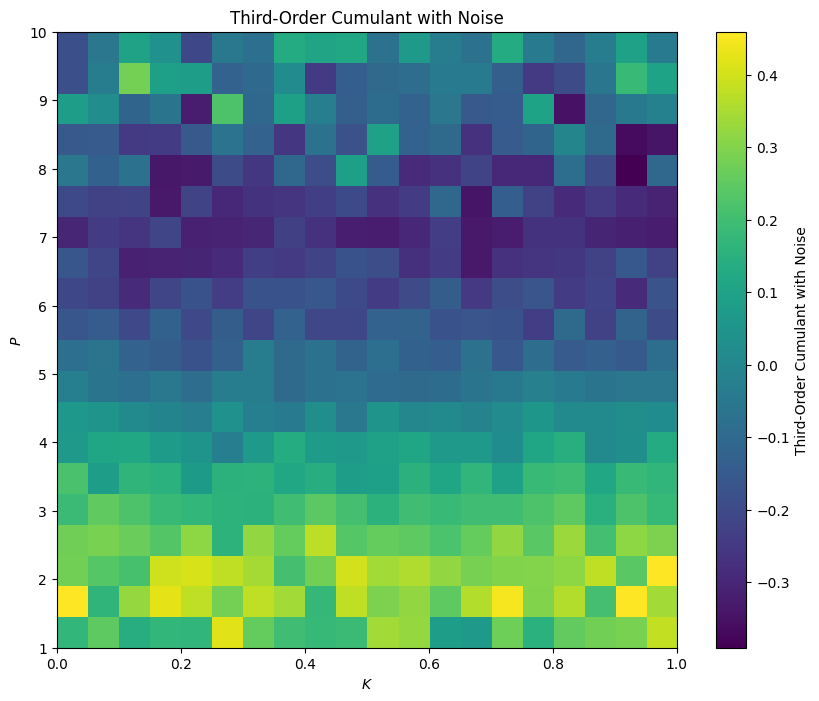

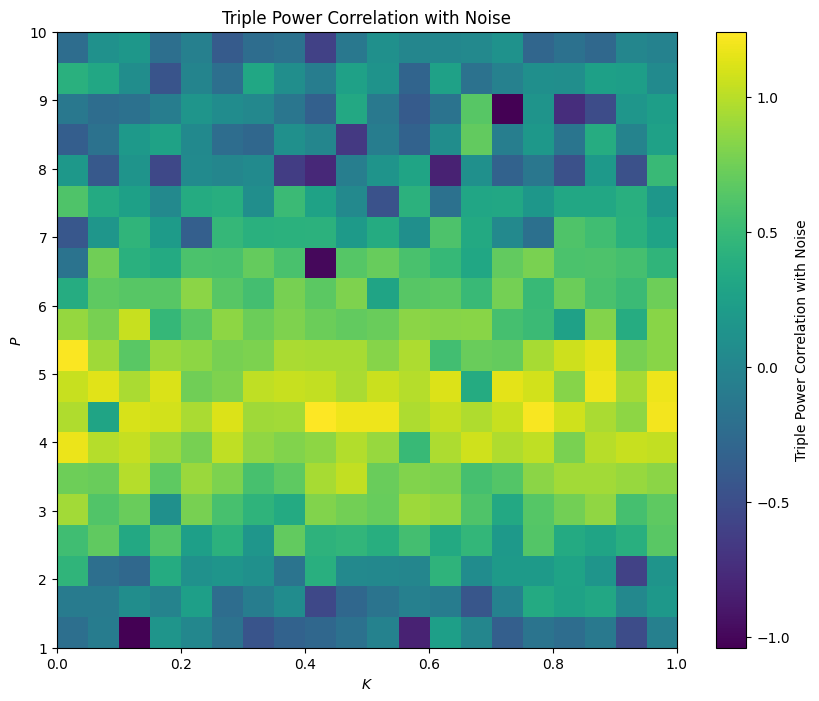

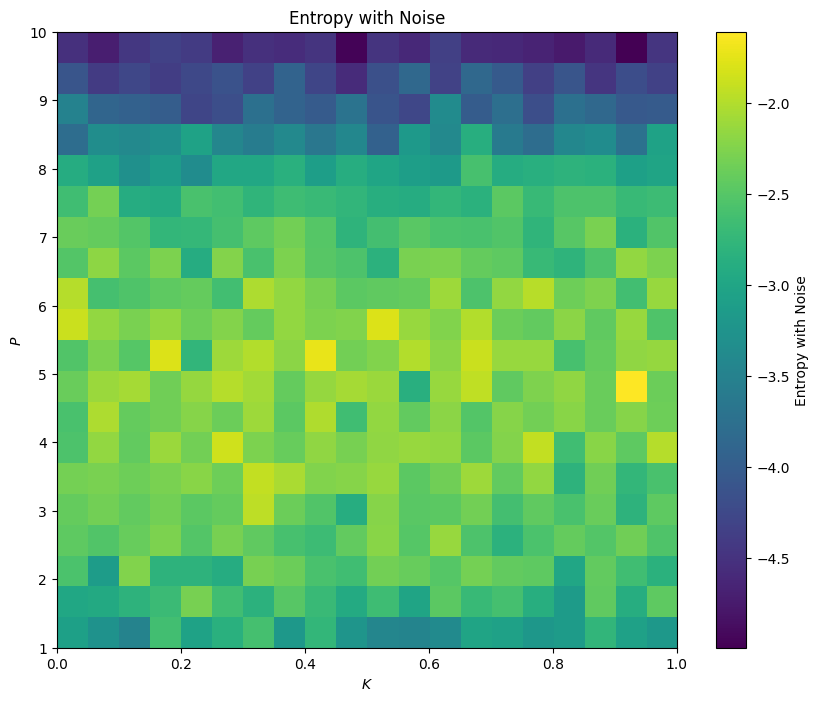

In [28]:
# Matrices to store metrics with noise
TC_map_noise = np.zeros((len(P_values), len(K3_values)))
DTC_map_noise = np.zeros((len(P_values), len(K3_values)))
Cumulant_map_noise = np.zeros((len(P_values), len(K3_values)))
PowerCorr_map_noise = np.zeros((len(P_values), len(K3_values)))
Entropy_map_noise = np.zeros((len(P_values), len(K3_values)))  # Nueva métrica

state0 = 0.1 * np.random.randn(2 * N_nodes)

for i, P_val in enumerate(P_values):
    for j, K3_val in enumerate(K3_values):
        # Simulation with noise using the existing function for higher-order interactions
        t, states = simulate_wc_stochastic(state0, P_val, K_val, M, T, dt, sigma_E=sigma_E, higher_order=False)

        # Remove transient
        start_idx = int(0.3 * len(t))
        E = states[start_idx:, :N_nodes]

        # Data matrix for higher-order metrics
        X = E.copy()

        # Covariance matrix
        Sigma = np.cov(X.T)

        # Higher-order metrics using the existing functions
        TC_map_noise[i, j] = TC_gauss(Sigma)
        DTC_map_noise[i, j] = DTC_gauss(Sigma)
        Entropy_map_noise[i, j] = entropy_gauss(Sigma)  # Cálculo de la entropía
        if X.shape[1] == 3:
            Cumulant_map_noise[i, j] = cumulants(X)
            PowerCorr_map_noise[i, j] = powercorr(X)

    if (i + 1) % 5 == 0:
        print(f"Progress: {i+1}/{len(P_values)}")

# Visualization using the existing functions
plot_metrics_map(TC_map_noise, P_values, K3_values, title="Total Correlation (TC) with Noise")
plot_metrics_map(DTC_map_noise, P_values, K3_values, title="Dual Total Correlation (DTC) with Noise")
plot_metrics_map(Cumulant_map_noise, P_values, K3_values, title="Third-Order Cumulant with Noise")
plot_metrics_map(PowerCorr_map_noise, P_values, K3_values, title="Triple Power Correlation with Noise")
plot_metrics_map(Entropy_map_noise, P_values, K3_values, title="Entropy with Noise") 

In [41]:
from Scripts.simulation import simulate_wc

# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
TC_no_noise = TC_gauss(Sigma_no_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")


Third-Order Cumulant (sin ruido): 1.3082027437397068
Total Correlation (sin ruido): 1.8288071391913177


In [40]:
from Scripts.simulation import simulate_wc_stochastic

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E)

# Extraer señales
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_with_noise = np.cov(E_with_noise.T)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_with_noise.shape[1] == 3:
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (con ruido): {TC_with_noise}")



Third-Order Cumulant (con ruido): 1.083329471915314
Total Correlation (con ruido): 0.7201733820874734


In [38]:
# Generar señales independientes
E_independent = np.random.randn(len(t), N_nodes)

# Calcular métricas
Sigma_independent = np.cov(E_independent.T)
TC_independent = TC_gauss(Sigma_independent)

if E_independent.shape[1] == 3:
    cumulant_independent = cumulants(E_independent)
    print(f"Third-Order Cumulant (independent): {cumulant_independent}")

print(f"Total Correlation (independent): {TC_independent}")


Third-Order Cumulant (independent): -0.000653825358119353
Total Correlation (independent): 1.3920149881663235e-05


In [29]:
# Parámetros de simulación
P_sim = 1.0  # Cambiar el valor de P
K_sim = 0.0  # Fuerza de acoplamiento pairwise
state0 = np.random.randn(2 * N_nodes)  # Condiciones iniciales

# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=0.01)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
Sigma_with_noise = np.cov(E_with_noise.T)

TC_no_noise = TC_gauss(Sigma_no_noise)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")
print(f"Total Correlation (con ruido): {TC_with_noise}")


Third-Order Cumulant (sin ruido): 4.308787552382417
Third-Order Cumulant (con ruido): 3.8129792400179197
Total Correlation (sin ruido): 0.7359186128026374
Total Correlation (con ruido): 0.6574386992515842


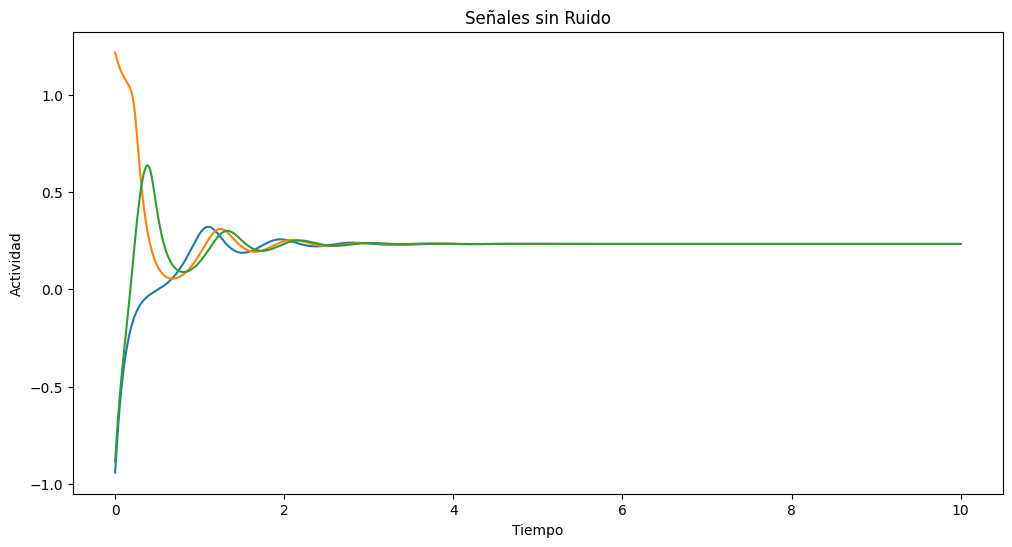

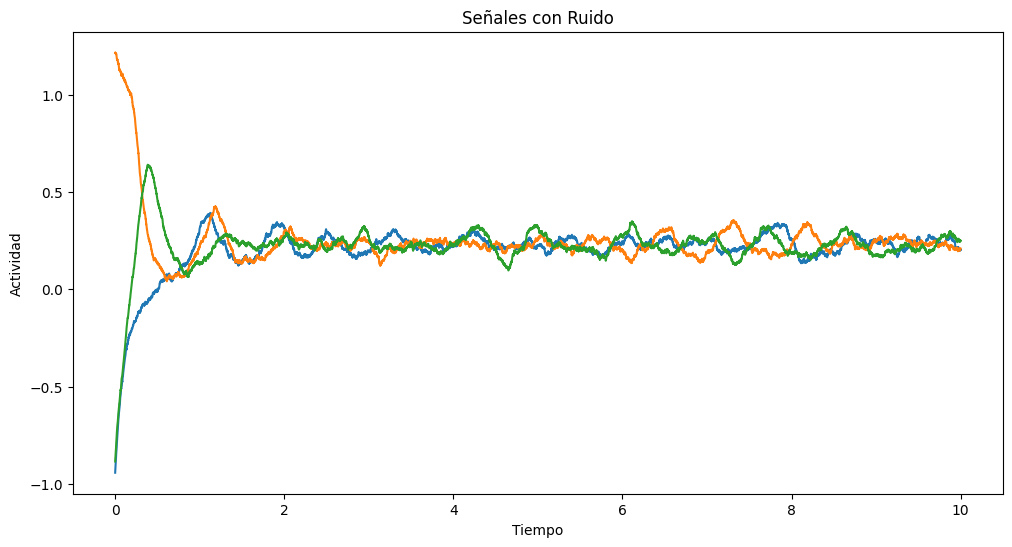

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(t, E_no_noise)
plt.title("Señales sin Ruido")
plt.xlabel("Tiempo")
plt.ylabel("Actividad")
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(t, E_with_noise)
plt.title("Señales con Ruido")
plt.xlabel("Tiempo")
plt.ylabel("Actividad")
plt.show()


In [ ]:
TC_map_noise

array([[1.17452964, 0.30264733, 1.13307443, 0.93676924, 0.6443305 ,
        0.81300497, 0.48345049, 0.95714909, 0.7491508 , 0.8358907 ,
        0.82288792, 0.11623616, 1.4875157 , 1.11620656, 0.28405885,
        0.93127849, 0.68034064, 0.34935457, 0.47649649, 0.60843808],
       [0.99625275, 1.35424681, 1.30830819, 1.37162579, 1.38019178,
        1.26764826, 1.7409459 , 1.28718752, 0.99275779, 1.32946337,
        1.45986332, 1.04302005, 1.29887984, 1.52602959, 1.23242731,
        1.34000131, 0.76980336, 1.2492151 , 1.31437953, 1.48294996],
       [1.53948137, 1.26180639, 1.23803241, 1.52945516, 1.82996071,
        1.71682487, 1.48202675, 1.66023866, 1.90331845, 1.94160012,
        1.55129889, 1.55946587, 1.53901441, 1.81473492, 1.62221683,
        1.72073717, 2.01697953, 1.86708581, 1.3782315 , 1.5878307 ],
       [1.86116728, 1.68337167, 1.47321007, 1.99309534, 1.75764521,
        1.41049342, 1.55388244, 1.75597788, 1.89839621, 1.91806333,
        1.58307883, 1.95901814, 1.81841076, 1

In [ ]:
P_values, K3_values,

(array([ 1.        ,  1.47368421,  1.94736842,  2.42105263,  2.89473684,
         3.36842105,  3.84210526,  4.31578947,  4.78947368,  5.26315789,
         5.73684211,  6.21052632,  6.68421053,  7.15789474,  7.63157895,
         8.10526316,  8.57894737,  9.05263158,  9.52631579, 10.        ]),
 array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
        0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
        0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
        0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ]))

 P_values, K3_values,

In [31]:
def TC_gauss(Sigma):
    n = Sigma.shape[0]
    H_marginals = 0.0
    for i in range(n):
        H_marginals += entropy_gauss(np.array([[Sigma[i, i]]]))
    H_Sigma = entropy_gauss(Sigma)
    return H_marginals - H_Sigma

def entropy_gauss(Sigma):
    n = Sigma.shape[0]
    Sigma += 1e-9 * np.eye(n)  # Añadir un pequeño término para evitar singularidades
    det = np.linalg.det(Sigma)
    if det <= 0:
        det = 1e-9
    return (n / 2) * np.log(2 * np.pi * np.e) + 0.5 * np.log(det)

In [49]:
from Scripts.simulation import simulate_wc
state0 = np.random.randn(2 * N_nodes)
# Simulación sin ruido
t, states_no_noise = simulate_wc(state0, P_sim, K_sim, M, T, dt)

# Extraer señales
E_no_noise = states_no_noise[:, :N_nodes]

# Calcular métricas
Sigma_no_noise = np.cov(E_no_noise.T)
TC_no_noise = TC_gauss(Sigma_no_noise)

if E_no_noise.shape[1] == 3:
    cumulant_no_noise = cumulants(E_no_noise)
    print(f"Third-Order Cumulant (sin ruido): {cumulant_no_noise}")

print(f"Total Correlation (sin ruido): {TC_no_noise}")


Third-Order Cumulant (sin ruido): -0.7960012705273511
Total Correlation (sin ruido): 0.20508634041248208


In [50]:
from Scripts.simulation import simulate_wc_stochastic
state0 = np.random.randn(2 * N_nodes)

# Simulación con ruido
t, states_with_noise = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=1)

# Extraer señales
E_with_noise = states_with_noise[:, :N_nodes]

# Calcular métricas
Sigma_with_noise = np.cov(E_with_noise.T)
TC_with_noise = TC_gauss(Sigma_with_noise)

if E_with_noise.shape[1] == 3:
    cumulant_with_noise = cumulants(E_with_noise)
    print(f"Third-Order Cumulant (con ruido): {cumulant_with_noise}")

print(f"Total Correlation (con ruido): {TC_with_noise}")


Third-Order Cumulant (con ruido): 0.022429238710911528
Total Correlation (con ruido): 0.005699298828358401


In [43]:
# Generar señales independientes
E_independent = np.random.randn(len(t), N_nodes)

# Calcular métricas
Sigma_independent = np.cov(E_independent.T)
TC_independent = TC_gauss(Sigma_independent)

if E_independent.shape[1] == 3:
    cumulant_independent = cumulants(E_independent)
    print(f"Third-Order Cumulant (independent): {cumulant_independent}")

print(f"Total Correlation (independent): {TC_independent}")

Third-Order Cumulant (independent): 0.004448351104103893
Total Correlation (independent): 0.0001887544153209575


In [46]:
from Scripts.simulation import simulate_wc_stochastic
from Scripts.parameters import N_nodes, M, T, dt, sigma_E, P_values, K_values

# Parámetros de simulación
P_sim = 5.0
K_sim = 0.0  # Fuerza de acoplamiento pairwise
state0 = np.random.randn(2 * N_nodes)  # Condiciones iniciales

# Simulación con ruido
t, states = simulate_wc_stochastic(state0, P_sim, K_sim, M, T, dt, sigma_E=sigma_E, higher_order=False)

# Extraer señales
E = states[:, :N_nodes]
I = states[:, N_nodes:]
